# **7. GRU**

## **7.1. Librerias**

In [1]:
import os
import copy
import random
import optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

import geopandas as gpd
from libpysal.weights import Queen
import sys
import time


## **7.2. Configuración Reproducibilidad**

In [2]:
SEEDS = [42, 123, 2024]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]
Torch: 2.11.0+cu130
Numpy: 2.2.6
Pandas: 2.3.3


El entorno de ejecución utiliza PyTorch 2.11 con soporte CUDA 13.0 y una GPU NVIDIA GeForce RTX 5050 Laptop, lo que permite acelerar significativamente el entrenamiento de modelos de deep learning. Además, la configuración de semillas múltiples y versiones recientes de librerías como NumPy y Pandas favorece la reproducibilidad y estabilidad experimental.


In [3]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed fijada: {seed}")


def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()

Este código implementa una estrategia exhaustiva de **reproducibilidad en experimentos con PyTorch**, fijando semillas en `random`, `numpy` y `torch`, además de desactivar optimizaciones no deterministas de CUDA (como `cudnn.benchmark`) para garantizar resultados consistentes entre ejecuciones. Asimismo, se controla la aleatoriedad en los *data loaders* mediante `seed_worker` y un generador de PyTorch, asegurando coherencia en el muestreo paralelo de datos.

## **7.3. Carga de Datos & Preprocesamiento**

### **7.3.1. Carga de Datos**

In [4]:
df = pd.read_csv("/home/guirlessa/Dl_Proyecto_Dengue/Bases_Datos/df_full.csv")
df.head()

,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


In [5]:
print("El dataframe tiene {0} filas y {1} columnas.".format(df.shape[0], df.shape[1]))

El dataframe tiene 21664 filas y 54 columnas.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21664 entries, 0 to 21663
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   departamento        21664 non-null  object 
 1   fecha_inicio        21664 non-null  object 
 2   ano                 21664 non-null  int64  
 3   semana              21664 non-null  int64  
 4   casos               21664 non-null  float64
 5   casos_mujeres       21664 non-null  int64  
 6   casos_hombres       21664 non-null  int64  
 7   casos_rural         21664 non-null  int64  
 8   casos_urbano        21664 non-null  int64  
 9   (0_5]               21664 non-null  int64  
 10  (5_13]              21664 non-null  int64  
 11  (13_26]             21664 non-null  int64  
 12  (26_60]             21664 non-null  int64  
 13  60_mas              21664 non-null  int64  
 14  casos_Contributivo  21664 non-null  int64  
 15  casos_No_asegurado  21664 non-null  int64  
 16  caso

Se observa que la variable `fecha_inicio` está tipificada como `object`, cuando en realidad debería corresponder al tipo `datetime`. Por ello, se procederá a realizar la conversión adecuada para garantizar un manejo correcto de fechas en las etapas posteriores de modelado.

In [7]:
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])

También se procede a organizar los registros del DataFrame según el departamento y la fecha de inicio, con el objetivo de asegurar una estructura temporal coherente que facilite el análisis y el posterior proceso de modelado.

In [8]:
df = df.sort_values(
    ["departamento", "fecha_inicio"]
).reset_index(drop=True)


### **7.3.2. Feature Enginering**

Con el fin de incorporar la estacionalidad anual de la enfermedad, se construyeron las variables cíclicas week_sin y week_cos a partir de la semana epidemiológica normalizada. Esta transformación permite representar la naturaleza periódica del calendario, preservando la continuidad entre el final y el inicio de cada año, y facilitando que los modelos capturen patrones estacionales recurrentes asociados a la transmisión del dengue.

In [9]:
weeks_per_year = df.groupby("ano")["semana"].transform("max")

df["week_norm"] = df["semana"] / weeks_per_year

df["week_sin"] = np.sin(2 * np.pi * df["week_norm"])

df["week_cos"] = np.cos(2 * np.pi * df["week_norm"])

Este conjunto de `FEATURES` define el espacio de variables utilizado para el modelado, combinando información temporal, climática y sociodemográfica. En particular, se incorporan múltiples **rezagos (lags)** de la incidencia y variables meteorológicas (temperatura, humedad y precipitación) para capturar dependencias temporales y efectos retardados, junto con variables estructurales como población y proporción rural. Adicionalmente, las componentes cíclicas `week_sin` y `week_cos` permiten modelar la estacionalidad semanal de forma continua, evitando discontinuidades propias de una codificación directa del tiempo.

In [10]:
FEATURES = [

    "inc_lag_1",
    "inc_lag_2",
    "inc_lag_3",
    "inc_lag_4",
    "inc_lag_8",
    "inc_lag_12",
    "inc_lag_20",

    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_4",
    "temp_lag_8",
    "temp_lag_12",
    "temp_lag_20",

    "humedad_lag_1",
    "humedad_lag_2",
    "humedad_lag_4",
    "humedad_lag_8",
    "humedad_lag_12",
    "humedad_lag_20",

    "precip_lag_1",
    "precip_lag_2",
    "precip_lag_4",
    "precip_lag_8",
    "precip_lag_12",
    "precip_lag_20",

    "poblacion",
    "prop_rural",

    "week_sin",
    "week_cos"
]

Asimismo, durante el análisis exploratorio de datos se observó que la variable de incidencia presentaba una distribución fuertemente asimétrica hacia la derecha, caracterizada por la presencia de valores extremos asociados a periodos epidémicos. Debido a ello, se consideró necesario aplicar una transformación logarítmica con el objetivo de reducir la asimetría, estabilizar la varianza y facilitar que los modelos capturen de manera más adecuada la estructura temporal y los patrones subyacentes de la incidencia del dengue.

In [11]:
df["incidencia_log"] = np.log1p(df["incidencia"])

TARGET = "incidencia_log"

Con el fin de evaluar el efecto de la transformación logarítmica, se compararon las distribuciones de la incidencia antes y después del preprocesamiento. La distribución original presentaba una marcada asimetría positiva y una alta concentración de valores extremos asociados a periodos epidémicos. Tras aplicar la transformación logarítmica (log1p), se observó una reducción significativa del sesgo y una distribución más equilibrada, lo que contribuye a estabilizar la varianza y facilita la identificación de patrones temporales por parte de los modelos predictivos.

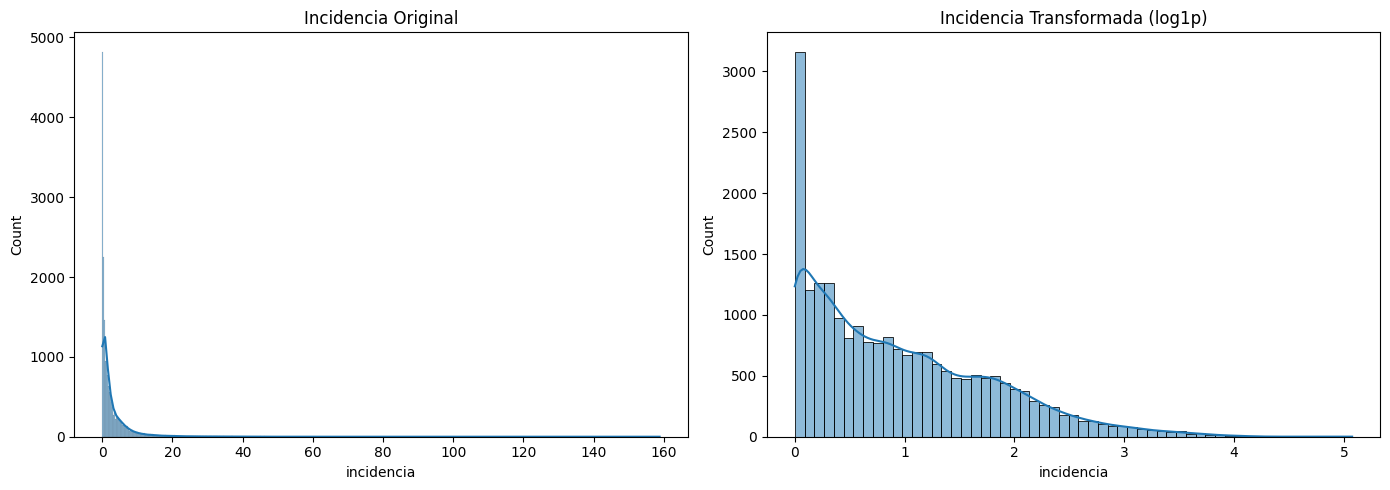

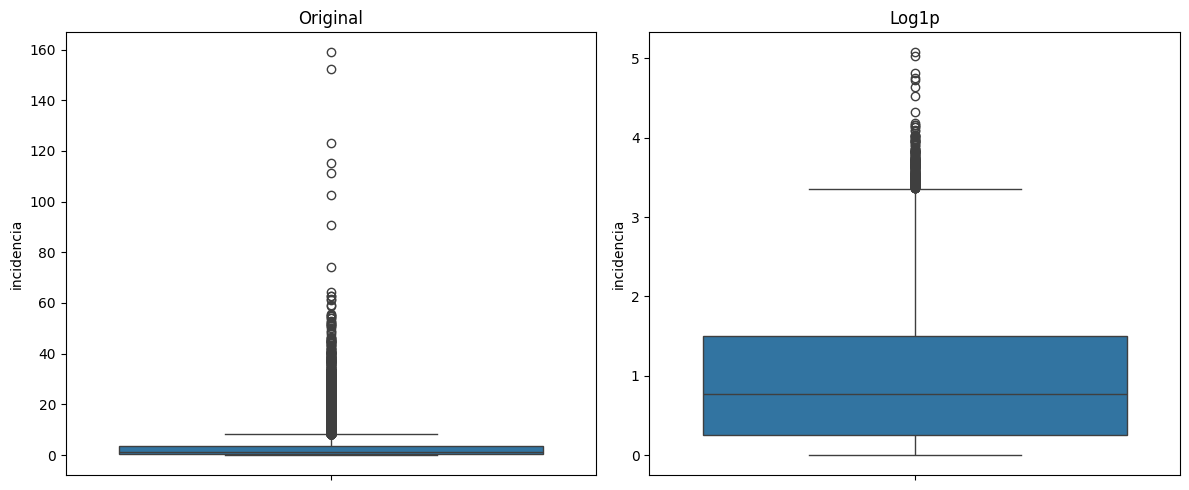

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["incidencia"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Incidencia Original")

sns.histplot(
    np.log1p(df["incidencia"]),
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Incidencia Transformada (log1p)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["incidencia"], ax=axes[0])
axes[0].set_title("Original")

sns.boxplot(y=np.log1p(df["incidencia"]), ax=axes[1])
axes[1].set_title("Log1p")

plt.tight_layout()
plt.show()

In [13]:
NUM_NODES = df["departamento"].nunique()

### **7.3.3. Normalización de los Datos**

Se plantea la función `scale_data` con el fin de aplicar una **normalización robusta (RobustScaler)** a los datos de entrenamiento y validación, para así preservar la estructura original de series temporales multivariadas. Para ello, primero reestructura los tensores a dos dimensiones para ajustar el escalador únicamente sobre el conjunto de entrenamiento, evitando *data leakage*, y luego transforma ambos conjuntos antes de devolverlos a su forma original.

In [14]:
def scale_data(X_train, X_val):

    scaler = RobustScaler()

    _, _, _, n_features = X_train.shape

    X_train_2d = X_train.reshape(-1, n_features)

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler

## **7.4. Esquema de validación temporal**

Se implementa un esquema de **validación cruzada temporal anidada (nested time series cross-validation)**, en el cual los datos se dividen respetando estrictamente el orden cronológico para evitar *data leakage*. En el nivel externo, se definen particiones de entrenamiento y prueba por año (2022–2024), simulando un escenario real de predicción futura; mientras que en el nivel interno, el conjunto de entrenamiento se subdivide nuevamente en conjuntos de entrenamiento y validación (2019–2021) para ajuste de hiperparámetros y selección de modelos. Este enfoque garantiza una evaluación más robusta y realista al emular la dinámica de predicción en series temporales.

In [15]:
def create_outer_folds(df, date_col="fecha_inicio"):

    folds       = []
    outer_years = [2022, 2023, 2024]

    for test_year in outer_years:

        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()

        folds.append({
            "test_year": test_year,
            "train_df":  train_df,
            "test_df":   test_df
        })

    return folds


outer_folds = create_outer_folds(df)

In [16]:
def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):

    inner_folds = []

    for val_year in val_years:

        inner_train = train_df[
            train_df["fecha_inicio"].dt.year < val_year
        ].copy()

        inner_val = train_df[
            train_df["fecha_inicio"].dt.year == val_year
        ].copy()

        inner_folds.append({
            "val_year":    val_year,
            "inner_train": inner_train,
            "inner_val":   inner_val
        })

    return inner_folds

## **7.5. Construcción de Ventanas de Tiempo**

Esta función implementa la construcción del conjunto de datos supervisado para modelado espaciotemporal, mediante la transformación de datos tabulares en tensores estructurados compatibles con arquitecturas de aprendizaje profundo. En primer lugar, reorganiza las variables explicativas y la variable objetivo a través de tablas pivote indexadas por fecha y departamento, asegurando consistencia en la representación espacial. Posteriormente, se unifican las variables en un tensor multivariado y se genera una estructura de secuencias mediante una estrategia de ventanas deslizantes (*sliding window*), en la que se define explícitamente un historial de observación (`window_size`) y un horizonte de predicción (`horizon`). Finalmente, se preserva información auxiliar como las fechas de referencia y el orden de los departamentos, lo cual es fundamental para mantener la coherencia temporal y espacial del conjunto de datos.


In [ ]:
def create_windows(
    df,
    features,
    target,
    window_size=12,
    horizon=4
):

    pivot_features = []

    for feat in features:

        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()

        pivot_features.append(pivot)

    dept_order = pivot_features[0].columns.tolist()


    pivot_features = [
        pf[dept_order].values for pf in pivot_features
    ]

    X_all = np.stack(pivot_features, axis=-1)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    target_pivot = target_pivot[dept_order]

    y_all = target_pivot.values
    dates = target_pivot.index.values

    X, y, base_dates = [], [], []

    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):

        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    base_dates = np.array(base_dates)

    return X, y, base_dates, dept_order

## **7.6. Funciones para el Modelado**

La clase EarlyStopping introduce un mecanismo de regularización basado en la detención anticipada del entrenamiento cuando la pérdida de validación deja de mejorar durante un número determinado de épocas (patience), lo cual ayuda a prevenir sobreajuste.

In [18]:
class EarlyStopping:

    def __init__(self, patience=20):

        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


Por otro lado, train_one_epoch y validate_one_epoch definen los ciclos estándar de entrenamiento y evaluación por época, respectivamente: la primera realiza la optimización del modelo mediante retropropagación del error, actualización de parámetros y recorte de gradientes para estabilizar el aprendizaje, mientras que la segunda evalúa el desempeño del modelo en modo inferencia sin actualización de pesos, permitiendo monitorear su generalización.

In [19]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()
    total_loss = 0

    for X_batch, y_batch in dataloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch)

        loss = criterion(pred, y_batch)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            loss = criterion(pred, y_batch)

            total_loss += loss.item()

    return total_loss / len(dataloader)

## **3.7. Arquitectura**

In [20]:
class GRUDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [21]:
class GRU(nn.Module):

    def __init__(
        self,
        num_nodes,
        in_channels,
        hidden_size=64,
        num_layers=2,
        horizon=4,
        dropout=0.1
    ):
        super().__init__()

        self.num_nodes = num_nodes
        self.horizon = horizon
        self.hidden_size = hidden_size

        self.gru = nn.GRU(
            input_size=num_nodes * in_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, horizon * num_nodes)
        )

    def forward(self, x, adj=None):

        batch, T, nodes, feats = x.shape

        x = x.reshape(batch, T, nodes * feats)

        out, _ = self.gru(x)

        last = out[:, -1, :]

        last = self.dropout(last)

        out = self.fc(last)

        out = out.reshape(batch, self.horizon, self.num_nodes)

        return out

## **7.8. Optimización de Hiperparametros**

Inicializamos el entorno experimental del pipeline de optimización y evaluación del modelo,  definiendo estructuras globales para almacenar resultados de múltiples etapas del experimento (tuning, validación cruzada, entrenamiento y evaluación final).

In [22]:
ALL_OPTUNA_TRIALS = []
ALL_OPTUNA_FOLDS = []
ALL_RESIDUALS = []
ALL_INFERENCE_TIME = []
ALL_BEST_PARAMS = []
ALL_RESULTS     = []
ALL_PREDICTIONS = []
ALL_LOSSES      = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()

INNER_FOLDS_TUNING = create_inner_folds(
    TUNING_DF,
    val_years=[2019, 2020, 2021]
)


Ahora, definimos **objetivo de optimización para el ajuste de hiperparámetros mediante Optuna**, evaluando distintas configuraciones del modelo GRU. Para cada *trial*, se muestrean hiperparámetros como tamaño de ventana, tasa de aprendizaje, tamaño de lote, número de capas, unidades ocultas y *dropout*, y se evalúan mediante validación cruzada en los *inner folds*. En cada partición se entrena el modelo, se aplica *early stopping* y se calcula el RMSE sobre el conjunto de validación, retornando finalmente el error promedio como métrica a minimizar.

In [ ]:
def objective(trial):

    window_size = trial.suggest_categorical("window_size", [4, 8, 12, 16])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)

    rmse_folds = []
    fold_errors = []

    for fold_id, fold in enumerate(INNER_FOLDS_TUNING):

        X_train, y_train, _, _ = create_windows(
            fold["inner_train"], FEATURES, TARGET, window_size, 4
        )

        X_val, y_val, _, _ = create_windows(
            fold["inner_val"], FEATURES, TARGET, window_size, 4
        )

        X_train_scaled, X_val_scaled, _ = scale_data(X_train, X_val)

        train_loader = DataLoader(
            GRUDataset(X_train_scaled, y_train),
            batch_size=batch_size,
            shuffle=False
        )

        val_loader = DataLoader(
            GRUDataset(X_val_scaled, y_val),
            batch_size=batch_size,
            shuffle=False
        )

        model = GRU(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        early_stopping = EarlyStopping(patience=10)

        for epoch in range(50):

            train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            val_loss = validate_one_epoch(model, val_loader, criterion, DEVICE)

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model.eval()

        preds, trues = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                pred = model(X_batch.to(DEVICE))

                preds.append(pred.cpu().numpy())
                trues.append(y_batch.numpy())

        preds = np.concatenate(preds)
        trues = np.concatenate(trues)

        rmse = np.sqrt(mean_squared_error(trues.flatten(), preds.flatten()))

        rmse_folds.append(rmse)

        fold_errors.append({
            "trial": trial.number,
            "seed": seed,
            "fold": fold_id,
            "rmse": rmse
        })

    rmse_mean = np.mean(rmse_folds)

    return rmse_mean

## **7.9. Pipeline Train, Validation & Test**

Ahora se procede a ejecutar el ciclo completo de entrenamiento, optimización y evaluación del modelo GRU bajo un esquema de validación cruzada temporal anidada. En este proceso, se realiza la búsqueda de hiperparámetros mediante Optuna para cada semilla, seguida del entrenamiento del modelo en los *outer folds* utilizando la mejor configuración obtenida. Finalmente, se evalúa el desempeño en el conjunto de prueba mediante métricas de error, registrando adicionalmente tiempos de entrenamiento e inferencia, así como predicciones y residuos para su análisis detallado posterior.

In [24]:
for seed in SEEDS:

    print("\n")
    print("="*100)
    print(f"SEED {seed}")
    print("="*100)

    set_seed(seed)

    sampler = optuna.samplers.TPESampler(seed=seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler
    )

    study.optimize(objective, n_trials=30)

    best_params = study.best_trial.params

    print(f"\nMejores hiperparámetros para seed {seed}:")
    print(best_params)

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/GRU/GRU_best_params_seed_{seed}.csv",
        index=False
    )

    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):

        print("\n")
        print("="*100)
        print(f"OUTER FOLD {outer_idx+1} | Test year: {outer_fold['test_year']}")
        print("="*100)

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        hidden_size   = best_params["hidden_size"]
        num_layers    = best_params["num_layers"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year = outer_train_df["fecha_inicio"].dt.year.max()

        final_train_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year < val_year
        ]

        final_val_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year == val_year
        ]

        X_train, y_train, train_dates, dept_order = create_windows(
            final_train_df, FEATURES, TARGET, window_size, 4
        )
        
        idx_to_dept = {i: d for i, d in enumerate(dept_order)}
        dept_to_idx = {d: i for i, d in enumerate(dept_order)}

        X_val, y_val, val_dates, _ = create_windows(
            final_val_df, FEATURES, TARGET, window_size, 4
        )

        X_test, y_test, test_dates, _ = create_windows(
            final_test_df, FEATURES, TARGET, window_size, 4
        )

        X_train_scaled, X_val_scaled, scaler = scale_data(X_train, X_val)

        X_test_scaled = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)

        train_dataset = GRUDataset(X_train_scaled, y_train)
        val_dataset   = GRUDataset(X_val_scaled,   y_val)
        test_dataset  = GRUDataset(X_test_scaled,  y_test)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        model = GRU(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )

        early_stopping = EarlyStopping(patience=20)

        best_model = None
        best_loss = np.inf

        total_train_time = 0.0

        for epoch in range(300):

            start_epoch = time.time()

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            scheduler.step(val_loss)

            epoch_time = time.time() - start_epoch
            total_train_time += epoch_time

            print(
                f"Epoch {epoch+1}"
                f" | Train {train_loss:.4f}"
                f" | Val {val_loss:.4f}"
                f" | Time {epoch_time:.2f}s"
            )

            ALL_LOSSES.append({
                "seed": seed,
                "outer_fold": outer_idx + 1,
                "test_year": outer_fold["test_year"],
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch_time": epoch_time
            })

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(model)

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model = best_model

        torch.save(
            model.state_dict(),
            f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/GRU/"
            f"gru_seed_{seed}_outer_fold_{outer_idx+1}.pt"
        )

        model.eval()

        start_inference = time.time()

        predictions = []
        targets = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(DEVICE)

                pred = model(X_batch.to(DEVICE))

                predictions.append(pred.cpu().numpy())
                targets.append(y_batch.numpy())

        inference_time = time.time() - start_inference

        predictions = np.concatenate(predictions)
        targets     = np.concatenate(targets)

        mse  = mean_squared_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(targets.flatten(), predictions.flatten())
        r2   = r2_score(targets.flatten(), predictions.flatten())

        ALL_RESULTS.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "train_time": total_train_time,
            "inference_time": inference_time
        })

        ALL_INFERENCE_TIME.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "inference_time": inference_time,
            "train_time": total_train_time
        })


        rows = []

        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):

                    y_true = targets[i, h, node]
                    y_pred = predictions[i, h, node]

                    residual = y_true - y_pred

                    rows.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,

                        "y_true_log": y_true,
                        "y_pred_log": y_pred,

                        "y_true_real": np.expm1(y_true),
                        "y_pred_real": np.expm1(y_pred),

                        "residual": residual,
                        "abs_error": abs(residual),
                        "sq_error": residual ** 2
                    })

                    ALL_RESIDUALS.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,
                        "residual": residual
                    })

        ALL_PREDICTIONS.append(pd.DataFrame(rows))



SEED 42


[I 2026-06-02 09:37:57,367] A new study created in memory with name: no-name-08a7fbe9-0821-46be-b57d-abce24e74929


Seed fijada: 42


[I 2026-06-02 09:38:12,943] Trial 0 finished with value: 0.7113001584851767 and parameters: {'window_size': 8, 'learning_rate': 0.0002051338263087451, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.4}. Best is trial 0 with value: 0.7113001584851767.
[I 2026-06-02 09:38:25,104] Trial 1 finished with value: 0.6671023923047255 and parameters: {'window_size': 4, 'learning_rate': 0.0004059611610484307, 'batch_size': 16, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1}. Best is trial 1 with value: 0.6671023923047255.
[I 2026-06-02 09:38:30,542] Trial 2 finished with value: 0.7116102648538373 and parameters: {'window_size': 8, 'learning_rate': 0.0015304852121831463, 'batch_size': 32, 'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4}. Best is trial 1 with value: 0.6671023923047255.
[I 2026-06-02 09:38:45,879] Trial 3 finished with value: 0.6887330004574487 and parameters: {'window_size': 12, 'learning_rate': 0.00017541893487450815, 'batch_size': 16, 'hidden_size': 32,


Mejores hiperparámetros para seed 42:
{'window_size': 16, 'learning_rate': 0.0007456514906831361, 'batch_size': 32, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.30000000000000004}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.9303 | Val 0.5939 | Time 0.13s
Epoch 2 | Train 0.4994 | Val 0.4657 | Time 0.13s
Epoch 3 | Train 0.3544 | Val 0.5933 | Time 0.12s
Epoch 4 | Train 0.3637 | Val 0.4632 | Time 0.12s
Epoch 5 | Train 0.3411 | Val 0.5256 | Time 0.10s
Epoch 6 | Train 0.3253 | Val 0.5681 | Time 0.10s
Epoch 7 | Train 0.3541 | Val 0.4602 | Time 0.11s
Epoch 8 | Train 0.3068 | Val 0.5431 | Time 0.10s
Epoch 9 | Train 0.2923 | Val 0.4043 | Time 0.11s
Epoch 10 | Train 0.2639 | Val 0.4055 | Time 0.10s
Epoch 11 | Train 0.2442 | Val 0.4187 | Time 0.09s
Epoch 12 | Train 0.2405 | Val 0.3509 | Time 0.10s
Epoch 13 | Train 0.2256 | Val 0.3774 | Time 0.12s
Epoch 14 | Train 0.2196 | Val 0.4049 | Time 0.11s
Epoch 15 | Train 0.2467 | Val 0.3935 | Time 0.08s
Epoch 16 | Train 0.2119 | Val 0.3658 | T

...

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1449: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(


Epoch 1 | Train 0.8096 | Val 1.2432 | Time 0.07s
Epoch 2 | Train 0.6600 | Val 0.7501 | Time 0.07s
Epoch 3 | Train 0.4866 | Val 0.5257 | Time 0.06s
Epoch 4 | Train 0.3789 | Val 0.5229 | Time 0.07s
Epoch 5 | Train 0.3586 | Val 0.6090 | Time 0.07s
Epoch 6 | Train 0.3934 | Val 0.5916 | Time 0.07s
Epoch 7 | Train 0.3637 | Val 0.5871 | Time 0.07s
Epoch 8 | Train 0.3172 | Val 0.5433 | Time 0.07s
Epoch 9 | Train 0.2983 | Val 0.5209 | Time 0.07s
Epoch 10 | Train 0.2989 | Val 0.4997 | Time 0.07s
Epoch 11 | Train 0.2940 | Val 0.5098 | Time 0.07s
Epoch 12 | Train 0.2897 | Val 0.5059 | Time 0.07s
Epoch 13 | Train 0.2766 | Val 0.4252 | Time 0.07s
Epoch 14 | Train 0.2868 | Val 0.4203 | Time 0.07s
Epoch 15 | Train 0.3035 | Val 0.5342 | Time 0.07s
Epoch 16 | Train 0.2649 | Val 0.5080 | Time 0.07s
Epoch 17 | Train 0.2728 | Val 0.4680 | Time 0.07s
Epoch 18 | Train 0.2620 | Val 0.4380 | Time 0.07s
Epoch 19 | Train 0.2517 | Val 0.4685 | Time 0.07s
Epoch 20 | Train 0.2539 | Val 0.5113 | Time 0.07s
Epoch 21 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1449: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(




OUTER FOLD 3 | Test year: 2024
Epoch 1 | Train 0.8318 | Val 1.1825 | Time 0.09s
Epoch 2 | Train 0.7118 | Val 1.4078 | Time 0.08s
Epoch 3 | Train 0.5173 | Val 0.8422 | Time 0.08s
Epoch 4 | Train 0.4320 | Val 0.8919 | Time 0.09s
Epoch 5 | Train 0.4478 | Val 0.7546 | Time 0.08s
Epoch 6 | Train 0.4097 | Val 0.5461 | Time 0.09s
Epoch 7 | Train 0.3997 | Val 0.6162 | Time 0.09s
Epoch 8 | Train 0.3583 | Val 0.6008 | Time 0.09s
Epoch 9 | Train 0.3263 | Val 0.6074 | Time 0.07s
Epoch 10 | Train 0.3237 | Val 0.5836 | Time 0.08s
Epoch 11 | Train 0.3204 | Val 0.5592 | Time 0.08s
Epoch 12 | Train 0.3244 | Val 0.5742 | Time 0.07s
Epoch 13 | Train 0.3187 | Val 0.6099 | Time 0.08s
Epoch 14 | Train 0.2980 | Val 0.6192 | Time 0.08s
Epoch 15 | Train 0.2832 | Val 0.7083 | Time 0.08s
Epoch 16 | Train 0.2994 | Val 0.7104 | Time 0.08s
Epoch 17 | Train 0.3231 | Val 0.5958 | Time 0.08s
Epoch 18 | Train 0.3227 | Val 0.6332 | Time 0.08s
Epoch 19 | Train 0.2705 | Val 0.6360 | Time 0.08s
Epoch 20 | Train 0.2581 | 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1449: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(


In [25]:
results_df        = pd.DataFrame(ALL_RESULTS)
predictions_df    = pd.concat(ALL_PREDICTIONS, axis=0)
losses_df         = pd.DataFrame(ALL_LOSSES)
best_params_df    = pd.DataFrame(ALL_BEST_PARAMS)

optuna_trials_df  = pd.DataFrame(ALL_OPTUNA_TRIALS)
optuna_folds_df   = pd.DataFrame(ALL_OPTUNA_FOLDS)

inference_df      = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df      = pd.DataFrame(ALL_RESIDUALS)

BASE_PATH = "/home/guirlessa/Dl_Proyecto_Dengue/Modelos/GRU"

results_df.to_csv(f"{BASE_PATH}/gru_results.csv", index=False)

predictions_df.to_csv(
    f"{BASE_PATH}/gru_predictions.csv",
    index=False
)

losses_df.to_csv(
    f"{BASE_PATH}/gru_training_history.csv",
    index=False
)

best_params_df.to_csv(
    f"{BASE_PATH}/gru_best_params.csv",
    index=False
)


optuna_trials_df.to_csv(
    f"{BASE_PATH}/gru_optuna_trials.csv",
    index=False
)

optuna_folds_df.to_csv(
    f"{BASE_PATH}/gru_optuna_folds.csv",
    index=False
)


inference_df.to_csv(
    f"{BASE_PATH}/gru_inference_time.csv",
    index=False
)


residuals_df.to_csv(
    f"{BASE_PATH}/gru_residuals.csv",
    index=False
)

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)

print(results_df.describe())


FINAL RESULTS
              seed  outer_fold    test_year       mse      rmse       mae  \
count     9.000000    9.000000     9.000000  9.000000  9.000000  9.000000   
mean    729.666667    2.000000  2023.000000  0.691701  0.816320  0.644820   
std     971.383421    0.866025     0.866025  0.295977  0.168782  0.148976   
min      42.000000    1.000000  2022.000000  0.431321  0.656750  0.517655   
25%      42.000000    1.000000  2022.000000  0.467398  0.683665  0.556838   
50%     123.000000    2.000000  2023.000000  0.557751  0.746827  0.567290   
75%    2024.000000    3.000000  2024.000000  0.954360  0.976914  0.775944   
max    2024.000000    3.000000  2024.000000  1.247772  1.117037  0.909754   

             r2  train_time  inference_time  
count  9.000000    9.000000        9.000000  
mean  -0.049927    5.071961        0.004384  
std    0.408662    3.037025        0.001620  
min   -0.852439    2.070219        0.002609  
25%   -0.318771    3.073506        0.002903  
50%    0.116227

## **7.10. Evaluando el Modelo**

In [26]:
MODEL_NAME = "GRU"
BASE_PATH = "Modelos/GRU"

results = pd.read_csv(f"{BASE_PATH}/gru_results.csv")
preds = pd.read_csv(f"{BASE_PATH}/gru_predictions.csv")
residuals = pd.read_csv(f"{BASE_PATH}/gru_residuals.csv")
history = pd.read_csv(f"{BASE_PATH}/gru_training_history.csv")

In [27]:
def compute_metrics(df, col_true='y_true_real', col_pred='y_pred_real', col_seed='seed'):
    metrics = []
    for seed in df[col_seed].unique():
        subset = df[df[col_seed] == seed]

        rmse = np.sqrt(mean_squared_error(subset[col_true], subset[col_pred]))
        mae = mean_absolute_error(subset[col_true], subset[col_pred])
        r2 = r2_score(subset[col_true], subset[col_pred])

        metrics.append({
            'seed': seed,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    return pd.DataFrame(metrics)


metrics_real = compute_metrics(preds)

print(metrics_real)

metrics_real.to_csv(f"{BASE_PATH}/metrics_gru.csv", index=False)

   seed      RMSE       MAE        R2
0    42  6.945436  3.931795  0.037472
1   123  7.574906  4.099742  0.103044
2  2024  7.298220  4.082630 -0.062792


El modelo GRU presenta un desempeño global deficiente y poco estable entre semillas, con RMSE elevados (≈6.95–7.57) y MAE altos (≈3.93–4.10), lo que indica errores de predicción significativos. El coeficiente de determinación es bajo en todos los casos (R² entre -0.06 y 0.10), llegando incluso a valores negativos, lo que evidencia ausencia de capacidad explicativa frente a un modelo base trivial. En conjunto, estos resultados muestran que la GRU no logra capturar adecuadamente la estructura del problema.

In [28]:
summary_real = metrics_real[['RMSE','MAE','R2']].agg(['mean','std'])

print("\nResumen GRU:\n", summary_real)


Resumen GRU:
           RMSE       MAE        R2
mean  7.272854  4.038056  0.025908
std   0.315501  0.092422  0.083521


El modelo GRU presenta un desempeño promedio bajo, con un RMSE de 7.27 y un MAE de 4.04, lo que refleja un nivel de error elevado en las predicciones. El coeficiente de determinación medio (R² ≈ 0.026) indica una capacidad explicativa prácticamente nula, cercana al comportamiento de un modelo no informativo. Aunque la desviación estándar del RMSE y MAE es moderada, la variabilidad del R² sugiere inestabilidad en la capacidad del modelo para capturar relaciones consistentes en los datos. En conjunto, el GRU muestra un desempeño débil tanto en precisión como en poder explicativo.

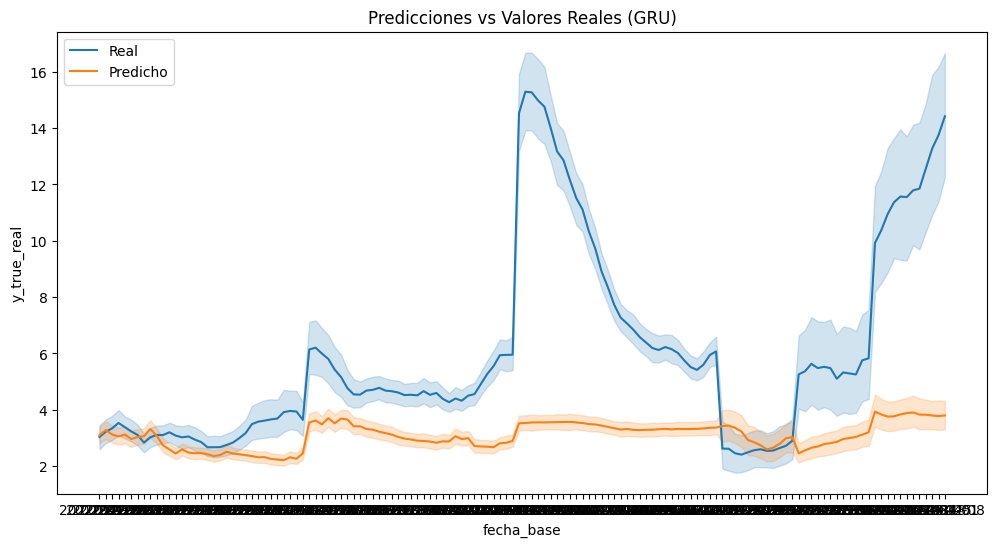

In [29]:
plt.figure(figsize=(12,6))
sns.lineplot(x='fecha_base', y='y_true_real', data=preds, label='Real')
sns.lineplot(x='fecha_base', y='y_pred_real', data=preds, label='Predicho')
plt.title("Predicciones vs Valores Reales (GRU)")
plt.legend()
plt.show()

La serie real presenta variaciones marcadas con picos pronunciados y alta amplitud, mientras que las predicciones del GRU se mantienen sistemáticamente en un rango más estrecho y de menor magnitud. Esto evidencia un sesgo de subestimación estructural, donde el modelo captura parcialmente la tendencia general de la serie, pero no logra reproducir la variabilidad ni los extremos de la distribución. En consecuencia, el ajuste es suave y amortiguado, lo que sugiere una capacidad limitada para modelar dinámicas no lineales de alta variabilidad.

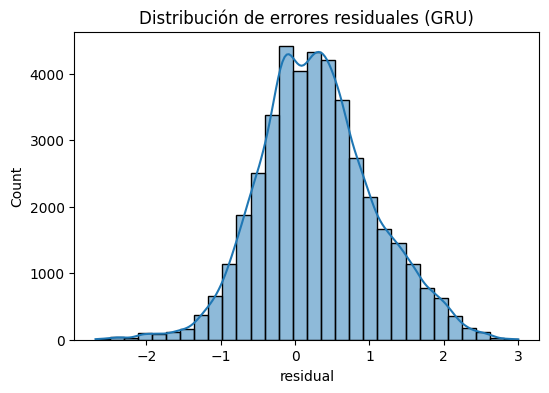

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(residuals['residual'], bins=30, kde=True)
plt.title("Distribución de errores residuales (GRU)")
plt.show()

El gráfico de distribución de residuos del GRU muestra una concentración de errores alrededor de cero, con una forma aproximadamente simétrica y unimodal, lo que sugiere que los residuos siguen una distribución cercana a la normal. La mayor densidad de observaciones se encuentra en el intervalo central, mientras que los errores extremos en ambas colas son relativamente poco frecuentes. Este comportamiento indica ausencia de sesgo sistemático claro (no predominan ni sobreestimaciones ni subestimaciones), aunque la concentración central no implica necesariamente buen desempeño, sino más bien errores moderados pero persistentes.

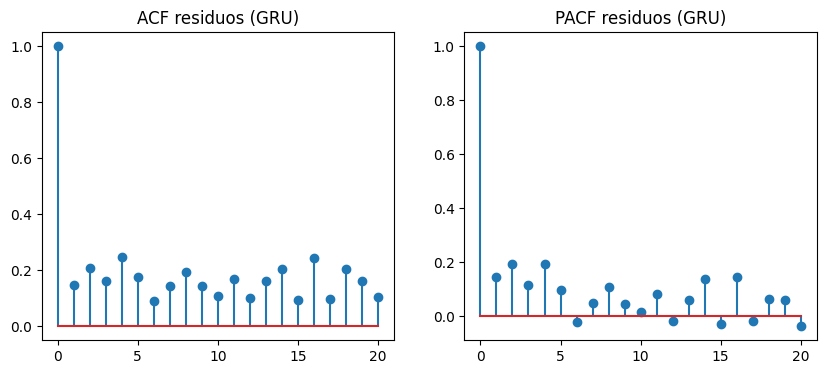

In [31]:
acf_vals = acf(residuals['residual'], nlags=20)
pacf_vals = pacf(residuals['residual'], nlags=20)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.stem(acf_vals)
plt.title("ACF residuos (GRU)")

plt.subplot(1,2,2)
plt.stem(pacf_vals)
plt.title("PACF residuos (GRU)")

plt.show()

El análisis de la ACF y PACF de los residuos del GRU muestra que no existen dependencias temporales significativas en los errores. En la ACF, los coeficientes decrecen rápidamente tras el rezago 0 y permanecen en valores bajos (inferiores a ~0.3) sin patrones persistentes, mientras que en la PACF no se observan picos relevantes en los rezagos posteriores, manteniéndose también en niveles reducidos. Este comportamiento indica ausencia de autocorrelación lineal remanente en los residuos, lo que sugiere que la estructura temporal principal ha sido capturada por el modelo. En conjunto, los residuos se aproximan a un proceso de ruido blanco, cumpliendo la condición de independencia temporal, aunque esto no implica necesariamente un buen ajuste en términos de magnitud del error.


In [32]:
lb = acorr_ljungbox(residuals['residual'], lags=[10, 20], return_df=True)
print(lb)

         lb_stat  lb_pvalue
10  11979.761606        0.0
20  23152.936909        0.0


El test de Ljung–Box aplicado a los residuos del modelo GRU muestra valores del estadístico extremadamente elevados (LB ≈ 11979.76 para 10 rezagos y ≈ 23152.94 para 20 rezagos), con p-values iguales a 0.0 en ambos casos. Esto implica el rechazo de la hipótesis nula de ausencia de autocorrelación, indicando que los residuos no son independientes en el tiempo. En consecuencia, a pesar de que las funciones ACF y PACF sugieren visualmente baja correlación lineal individual por rezago, el test global evidencia la presencia de dependencia temporal significativa en la estructura de los errores, lo que sugiere que el modelo GRU no ha capturado completamente la dinámica temporal subyacente del proceso.


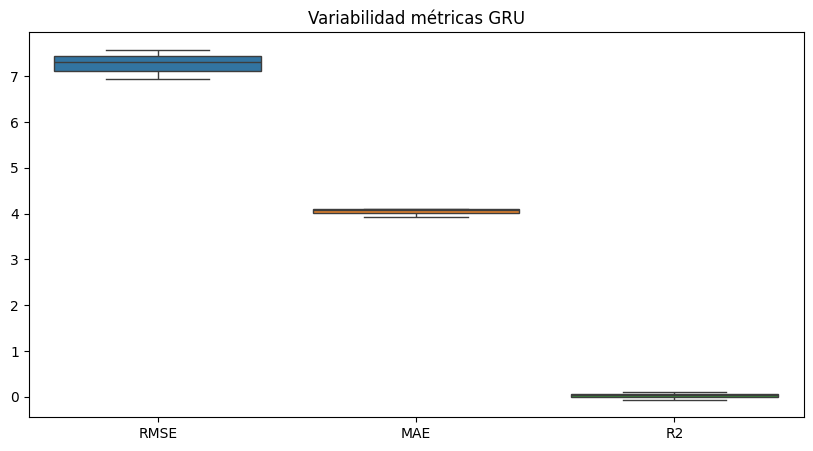

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(data=metrics_real[['RMSE','MAE','R2']])
plt.title("Variabilidad métricas GRU")
plt.show()

El RMSE se concentra en valores elevados (≈7–7.5), mostrando una dispersión relativamente baja pero consistente con un error absoluto alto. El MAE presenta valores alrededor de 4 con variabilidad reducida, lo que indica estabilidad en el error absoluto medio, aunque sin evidencia de mejora en su magnitud. Por su parte, el R² se mantiene cercano a cero con escasa dispersión, lo que confirma una capacidad explicativa débil y establemente pobre. En conjunto, el gráfico evidencia que el modelo GRU es consistente en su desempeño, pero dicha consistencia ocurre en un nivel de error elevado y con bajo poder predictivo.


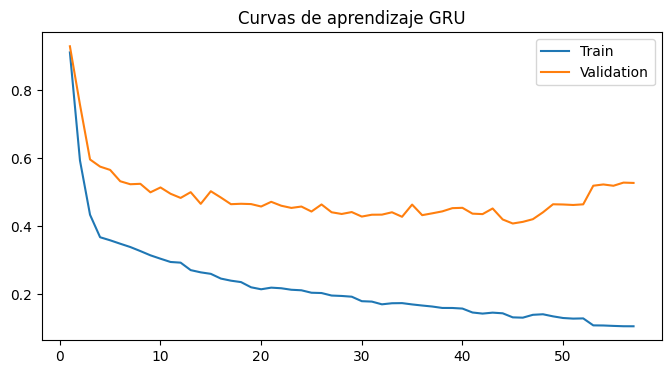

In [34]:
avg_history = history.groupby('epoch')[['train_loss','val_loss']].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(avg_history['epoch'], avg_history['train_loss'], label='Train')
plt.plot(avg_history['epoch'], avg_history['val_loss'], label='Validation')
plt.title("Curvas de aprendizaje GRU")
plt.legend()
plt.show()

Las curvas de aprendizaje del GRU muestran una reducción sostenida de la pérdida en el conjunto de entrenamiento, que desciende desde valores cercanos a 0.9 hasta aproximadamente 0.1, evidenciando capacidad de ajuste progresivo del modelo a los datos de entrenamiento. En contraste, la pérdida de validación disminuye inicialmente, pero se estabiliza alrededor de 0.4–0.5 sin continuar el mismo ritmo de mejora, lo que genera una brecha persistente entre ambas curvas. Este comportamiento indica una convergencia parcial con una generalización limitada, donde el modelo mejora su ajuste interno pero no traduce dicha mejora en un incremento equivalente del desempeño fuera de muestra, sugiriendo un nivel moderado de sobreajuste o saturación del aprendizaje en etapas tempranas del entrenamiento.

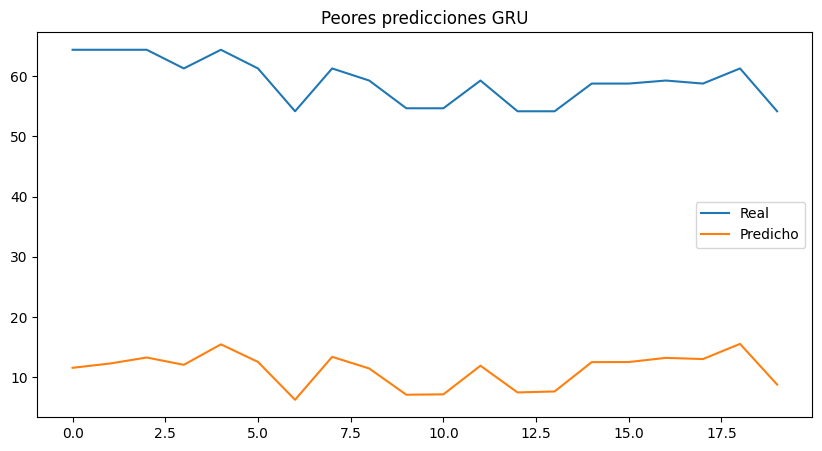

In [35]:
worst = preds.copy()
worst['error'] = abs(worst['y_true_real'] - worst['y_pred_real'])

worst_cases = worst.sort_values('error', ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.plot(worst_cases['y_true_real'].values, label='Real')
plt.plot(worst_cases['y_pred_real'].values, label='Predicho')
plt.title("Peores predicciones GRU")
plt.legend()
plt.show()

El gráfico “Peores predicciones GRU” evidencia un error de magnitud sistemáticamente elevado entre valores reales y predichos, caracterizado por una separación vertical casi constante en el rango aproximado de 45–50 unidades. Los valores reales oscilan entre ~54 y ~65, mientras que las predicciones se mantienen entre ~6 y ~16, lo que indica una desalineación en la escala de salida del modelo respecto a la variable objetivo. No obstante, ambas series exhiben una alta coherencia estructural en su dinámica temporal: los puntos de inflexión, picos y valles son reproducidos de forma sincronizada por el modelo, lo que sugiere que la dependencia temporal subyacente sí ha sido capturada.


In [36]:
def mean_ci(series):
    mean = np.mean(series)
    sem = st.sem(series)
    ci = st.t.interval(0.95, len(series)-1, loc=mean, scale=sem)
    return mean, ci
import scipy.stats as st

rmse_mean, rmse_ci = mean_ci(metrics_real['RMSE'])
mae_mean, mae_ci = mean_ci(metrics_real['MAE'])
r2_mean, r2_ci = mean_ci(metrics_real['R2'])

print("RMSE:", rmse_mean, rmse_ci)
print("MAE:", mae_mean, mae_ci)
print("R2:", r2_mean, r2_ci)

RMSE: 7.272853922020094 (np.float64(6.48910715404018), np.float64(8.056600690000007))
MAE: 4.0380556730538375 (np.float64(3.8084674664891347), np.float64(4.26764387961854))
R2: 0.025907978252424007 (np.float64(-0.1815684761725025), np.float64(0.23338443267735048))


El modelo GRU presenta un desempeño global bajo y estadísticamente inestable. El RMSE promedio es 7.27 con un intervalo de confianza amplio (≈6.49–8.06), lo que indica variabilidad considerable en el error de predicción entre ejecuciones. El MAE se sitúa en 4.04 (IC ≈ 3.81–4.27), confirmando un nivel de error absoluto elevado y consistente. En términos de capacidad explicativa, el R² promedio es muy cercano a cero (≈0.026) y su intervalo incluye valores negativos (≈-0.18 a 0.23), lo que implica que el modelo, en el peor de los casos, no supera un predictor trivial basado en la media. En conjunto, estos resultados evidencian un modelo con baja capacidad predictiva, limitada generalización y alta sensibilidad a la variabilidad del entrenamiento.
